# TP1 : Visión por Computadora I

Docente: Ing. Maxim Dorogov

Carrera de Especialización en Inteligencia Artificial  
Laboratorio de Sistemas Embebidos  
Facultad de Ingeniería de la Universidad de Buenos Aires  


Alumnos:  
- Francisco Julio Facchini Strohmayer  
- Elian Pinzas

**Consigna:**

- **Parte 1** (imágenes en `/white_patch`): implementar el algoritmo *White Patch* para
  corregir diferencias de color por iluminación, mostrar los resultados y analizar posibles
  fallas.
- **Parte 2**: leer `img1_tp.png` e `img2_tp.png` con OpenCV en escala de grises,
  visualizarlas, graficar y comparar sus histogramas, y discutir si los histogramas podrían
  servir como *features* para un modelo de clasificación/detección.


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

WP_DIR = "white_patch"   # carpeta con las imágenes de la consigna
IMG_DIR = "img"          # img1_tp.png, img2_tp.png


## Parte 1 : Algoritmo White Patch

### Idea

El color de la fuente de luz que ilumina una escena se mezcla con el color propio de los
objetos. Si la escena está iluminada con luz azul, verde o roja, toda la imagen queda con ese
"tinte", aunque el objeto en sí no haya cambiado de color.

El algoritmo **White Patch** asume que **el valor máximo que aparece en
cada canal de color es, en esa escena, el blanco bajo esa iluminación**. Entonces, para llevar
ese máximo al blanco puro (255) y reescalar el resto proporcionalmente:

$$R_{max}(I),\; G_{max}(I),\; B_{max}(I) \;=\; \text{valor máximo de cada canal en la imagen}$$

$$(R,G,B) \;\rightarrow\; \left(\frac{255}{R_{max}(I)}R,\; \frac{255}{G_{max}(I)}G,\; \frac{255}{B_{max}(I)}B\right)$$

Es decir: cada canal se escala por separado (por eso corrige el *tinte* de color, no solo el
brillo general), y se recorta (`clip`) a 255 por si el escalado empuja algún pixel por
encima del rango.


In [ ]:
def white_patch(img_bgr):
    """Aplica el algoritmo White Patch (por canal, escalado al máximo = 255).

    img_bgr: imagen en formato BGR (el que usa cv.imread), dtype uint8, 3 canales.
    """
    img = img_bgr.astype(np.float64)

    max_por_canal = img.max(axis=(0, 1))          # [Bmax, Gmax, Rmax]
    max_por_canal[max_por_canal == 0] = 1.0       # evita división por cero

    escalada = img * (255.0 / max_por_canal)
    escalada = np.clip(escalada, 0, 255).astype(np.uint8)
    return escalada


def cargar_rgb(path):
    """Lee con OpenCV (BGR) y descarta canal alpha si existe; devuelve RGB para graficar."""
    img = cv.imread(path, cv.IMREAD_UNCHANGED)
    if img.shape[2] == 4:              # RGBA -> nos quedamos con BGR
        img = img[:, :, :3]
    return img  # BGR, uint8


### Casos de control

Empezamos con tres versiones de la **misma escena** (una mano abierta repetida) fotografiada
bajo luz azul, verde y roja. Al ser una escena simple y controlada, es el mejor lugar para
verificar que el algoritmo funciona como se espera antes de probarlo en una escena más
compleja.


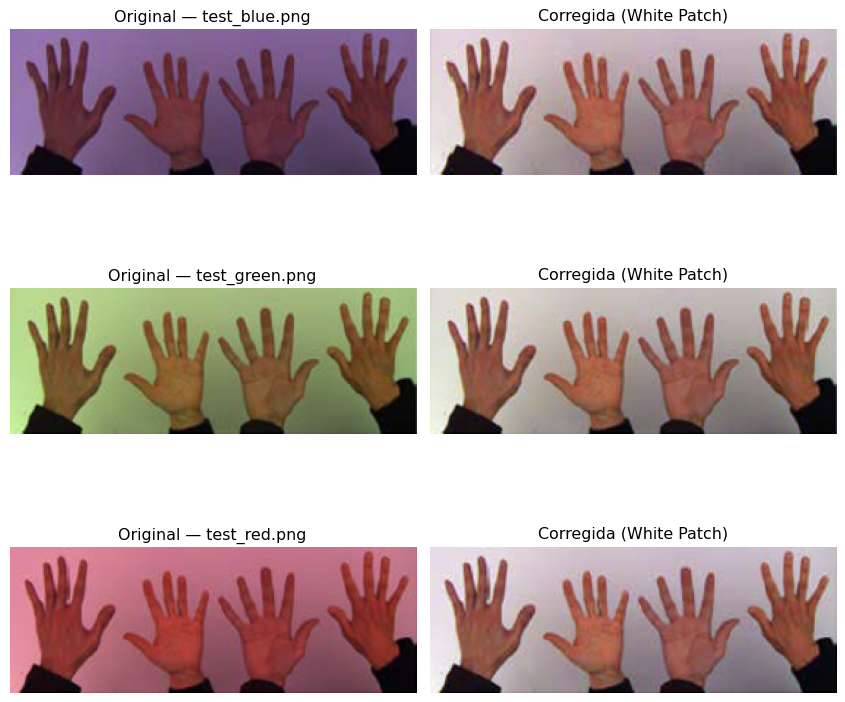

In [ ]:
casos_control = ["test_blue.png", "test_green.png", "test_red.png"]

fig, axes = plt.subplots(len(casos_control), 2, figsize=(9, 3 * len(casos_control)))
for i, nombre in enumerate(casos_control):
    bgr = cargar_rgb(f"{WP_DIR}/{nombre}")
    corregida = white_patch(bgr)

    axes[i, 0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Original — {nombre}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cv.cvtColor(corregida, cv.COLOR_BGR2RGB))
    axes[i, 1].set_title("Corregida (White Patch)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


**Qué se observa:** en los tres casos el fondo y la piel, que deberían verse parecidos
entre sí (misma escena, misma mano), quedan mucho más neutros y consistentes después de
aplicar White Patch. El tinte azul/verde/rojo dominante desaparece casi por completo porque
en estas imágenes sí hay una zona clara (la piel de la mano, bien iluminada) que funciona
como un buen "parche blanco" de referencia.


### Casos reales

Ahora aplicamos lo mismo sobre fotos de un objeto con muchos más detalles, texturas oscuras y
zonas con brillos (reflejos especulares en el plástico), bajo las mismas tres iluminaciones.


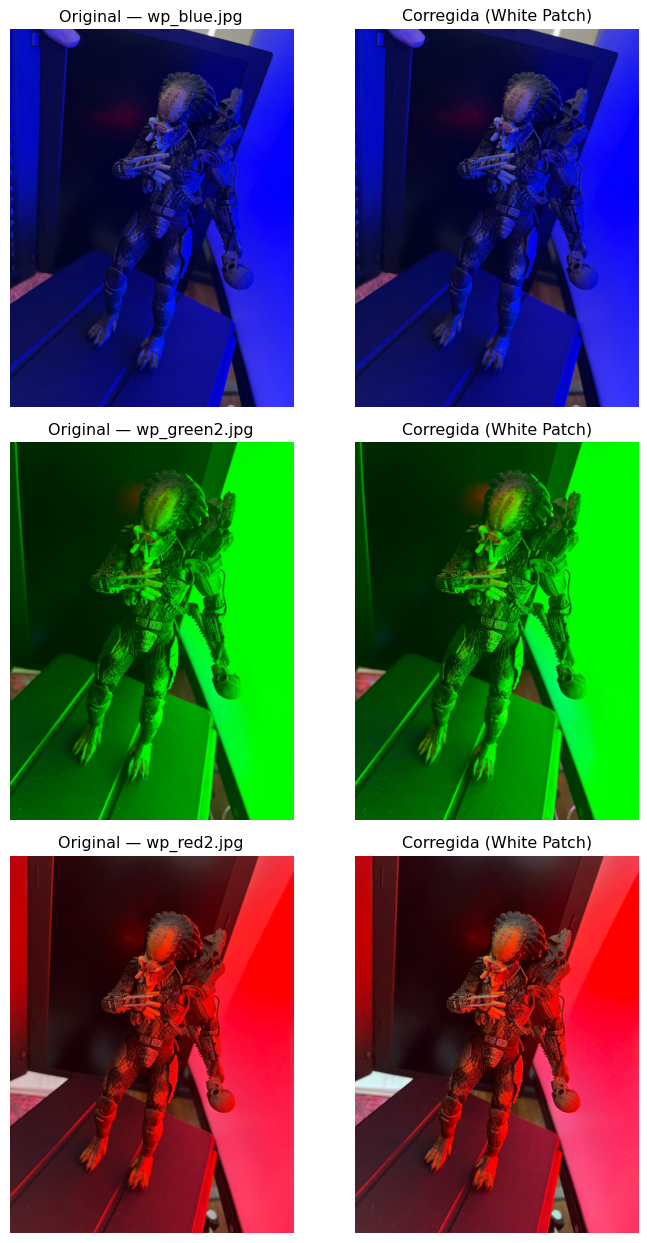

In [ ]:
casos_reales = ["wp_blue.jpg", "wp_green2.jpg", "wp_red2.jpg"]

fig, axes = plt.subplots(len(casos_reales), 2, figsize=(8, 4.4 * len(casos_reales)))
for i, nombre in enumerate(casos_reales):
    bgr = cargar_rgb(f"{WP_DIR}/{nombre}")
    corregida = white_patch(bgr)

    axes[i, 0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Original — {nombre}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cv.cvtColor(corregida, cv.COLOR_BGR2RGB))
    axes[i, 1].set_title("Corregida (White Patch)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


Además, la carpeta incluye dos versiones recortadas de las escenas verde y roja
(`wp_green.png`, `wp_red.png`), con canal alpha (RGBA). Las procesamos igual, descartando el
canal alpha, para ver si el recorte (que cambia qué zonas de brillo quedan dentro de la
imagen) afecta el resultado.


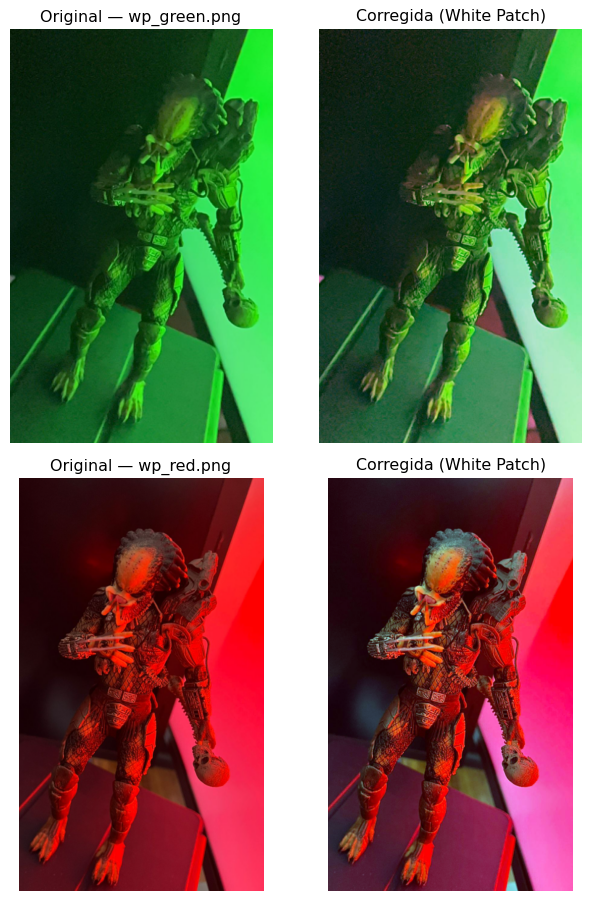

In [ ]:
casos_recortados = ["wp_green.png", "wp_red.png"]

fig, axes = plt.subplots(len(casos_recortados), 2, figsize=(7, 4.8 * len(casos_recortados)))
for i, nombre in enumerate(casos_recortados):
    bgr = cargar_rgb(f"{WP_DIR}/{nombre}")
    corregida = white_patch(bgr)

    axes[i, 0].imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Original — {nombre}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cv.cvtColor(corregida, cv.COLOR_BGR2RGB))
    axes[i, 1].set_title("Corregida (White Patch)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


### Resultados generales

**1. Resultados con éxito**: test_blue.png, test_green.png, test_red.png: en estas imágenes el algoritmo logró eliminar con gran éxito la componente de color en cada caso (azul, verde y rojo). En todas se observa un fondo de color claro y objetos en primer plano.

**2. Resultados con cambios (pero sin éxito)**: wp_green.png y wp_red.png: se observa en estas imágenes un cierto cambio en determinada región. Sin embargo, en el resultado general el algoritmo no fue capaz de eliminar la componente de iluminación

**3. Resultados con fracaso total**: wp_blue.jpg, wp_red2.jpg, wp_green2.jpg: en estas imágenes, el algoritmo no logró cambiar prácticamente nada.

### Análisis de las posibles fallas

En las fotos del muñeco, el resultado de White Patch es **notoriamente peor** que en la mano:
el tinte de color no se corrige del todo, y en algunos casos aparecen zonas quemadas
(saturadas) o con colores poco naturales. Esto tiene una explicación directa a partir de la
propia hipótesis del algoritmo:

- **La hipótesis de White Patch es que el píxel más brillante de cada canal es "blanco".**
  En las fotos del muñeco ese máximo casi siempre corresponde a un **reflejo especular**
  (un brillo puntual del plástico o de la superficie donde está apoyado), no a una superficie
  realmente blanca/neutra de la escena. Escalar todo el canal en función de ese único píxel
  "engañoso" produce una corrección incorrecta: el resto de la imagen se sobre-escala o
  sub-escala.
- **Es un algoritmo sensible a outliers**: al depender de un solo valor máximo por canal, un
  único píxel saturado (ruido, brillo, un reflejo) alcanza para arruinar la corrección de toda
  la imagen, aunque el 99,9% de los píxeles restantes fueran perfectamente normales.
- **Supone que existe al menos un objeto verdaderamente blanco/neutro en la escena**. En la
  mano esto se cumple razonablemente bien (la piel bien iluminada actúa como referencia). En
  la foto del muñeco no hay ninguna superficie genuinamente blanca, solo el material del
  muñeco y el fondo, ambos coloreados, así que no hay "blanco real" para anclar la corrección,
  y el algoritmo termina anclándose a lo que sea más brillante por casualidad.
- **El recorte de la imagen puede cambiar el resultado**: como el algoritmo depende del máximo
  de *toda la imagen*, si el recorte incluye o excluye la zona de brillo, el factor de escala
  cambia y por lo tanto también cambia cuánto se corrige el color (se ve comparando
  `wp_green.png`/`wp_red.png`, recortados, contra `wp_green2.jpg`/`wp_red2.jpg`, completos).

Conclusión/Síntesis: White Patch funciona bien cuando la escena efectivamente contiene una zona
blanca/neutra bien iluminada y sin reflejos especulares dominantes (como la mano); falla
cuando el "máximo" de la imagen es un brillo puntual no representativo del blanco real de la
escena (como en el muñeco).


## Parte 2 : Histogramas en escala de grises

Leemos `img1_tp.png` e `img2_tp.png` directamente en escala de grises con OpenCV.


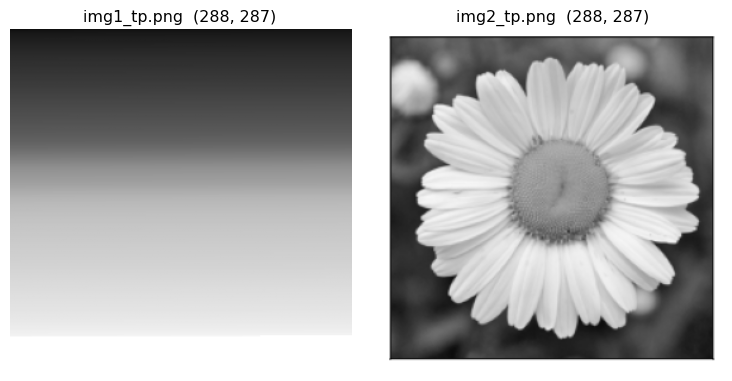

In [ ]:
img1 = cv.imread(f"{IMG_DIR}/img1_tp.png", cv.IMREAD_GRAYSCALE)
img2 = cv.imread(f"{IMG_DIR}/img2_tp.png", cv.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img1, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"img1_tp.png  {img1.shape}")
axes[0].axis("off")

axes[1].imshow(img2, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"img2_tp.png  {img2.shape}")
axes[1].axis("off")

plt.tight_layout()
plt.show()


`img1_tp.png` es un degradé continuo de gris a blanco (sin bordes ni textura), e
`img2_tp.png` es la foto de una flor con muchas zonas de contraste (pétalos claros, centro
texturado, fondo oscuro desenfocado). Visualmente son dos imágenes completamente distintas.

### Elección del número de bins

Con 256 bins (uno por nivel de gris) el histograma es más preciso pero también más ruidoso
pixel a pixel. Usamos **32 bins** (agrupando de a 8 niveles de gris): suficiente resolución
para distinguir las zonas de intensidad relevantes, sin que el ruido de a un nivel de gris
tape la forma general de la distribución.


img1: media=154.81  desvío=75.34
img2: media=154.81  desvío=75.34
¿Mismo multiset de valores de gris (misma imagen ordenada distinto)? True


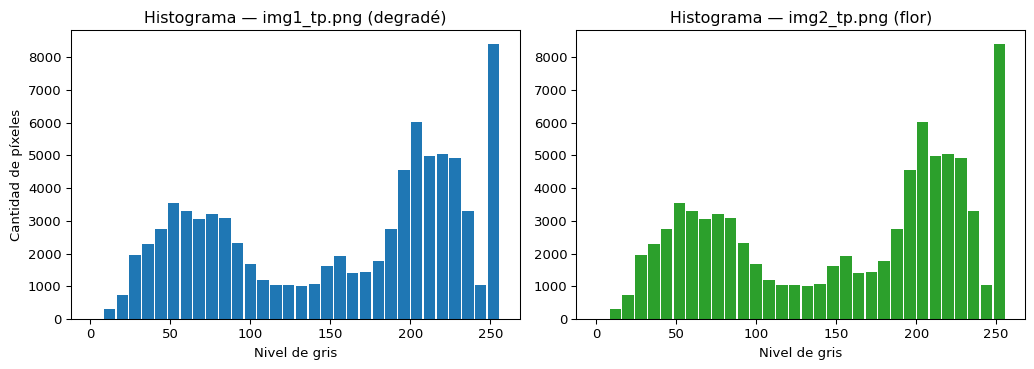

In [ ]:
N_BINS = 32

hist1 = cv.calcHist([img1], [0], None, [N_BINS], [0, 256]).flatten()
hist2 = cv.calcHist([img2], [0], None, [N_BINS], [0, 256]).flatten()

bin_edges = np.linspace(0, 256, N_BINS + 1)
centros = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
axes[0].bar(centros, hist1, width=256 / N_BINS * 0.9, color="tab:blue")
axes[0].set_title("Histograma — img1_tp.png (degradé)")
axes[0].set_xlabel("Nivel de gris")
axes[0].set_ylabel("Cantidad de píxeles")

axes[1].bar(centros, hist2, width=256 / N_BINS * 0.9, color="tab:green")
axes[1].set_title("Histograma — img2_tp.png (flor)")
axes[1].set_xlabel("Nivel de gris")

plt.tight_layout()
plt.show()

print(f"img1: media={img1.mean():.2f}  desvío={img1.std():.2f}")
print(f"img2: media={img2.mean():.2f}  desvío={img2.std():.2f}")
print("¿Mismo multiset de valores de gris (misma imagen ordenada distinto)?",
      (np.sort(img1.flatten()) == np.sort(img2.flatten())).all())


### Comparación y qué se observa

Lo primero que salta a la vista al graficar ambos histogramas es que **son exactamente
iguales**, barra por barra, se confirma también comparando la media, el desvío estándar y el
conjunto ordenado de valores de gris de ambas imágenes (celda anterior): `img1_tp.png` e
`img2_tp.png` contienen **exactamente los mismos valores de píxel**, solo que distribuidos en
posiciones distintas dentro de la imagen. En una (`img1`) esos valores están ordenados de
forma creciente de arriba hacia abajo (por eso se ve como un degradé); en la otra (`img2`) esos
mismos valores están distribuidos siguiendo la forma de una flor.

Esto no es una coincidencia menor: es el punto central que esta comparación buscaba
mostrar.

### ¿Sirven los histogramas como *features* para clasificación/detección?

Este caso es la mejor evidencia posible para responder que **no, no alcanzan por sí solos**:

- El histograma es, por construcción, **invariante a la posición espacial** de los valores de
  intensidad, solo cuenta cuántas veces aparece cada nivel de gris, sin importar dónde. Acá
  tenemos dos imágenes con contenido visual y estructura completamente distintos (un degradé
  liso vs. una foto con bordes, textura y un objeto reconocible) que, al ser reducidas a
  histograma, se vuelven **indistinguibles**.
- Un clasificador que usara únicamente el histograma de grises como *feature* jamás podría
  separar estas dos imágenes, aunque a simple vista sean obviamente diferentes. Cualquier
  información sobre bordes, formas, texturas o la posición relativa de los objetos se pierde
  por completo al colapsar la imagen a esta distribución 1D.
- Dicho esto, el histograma no es inútil: como descriptor **complementario** es barato de
  calcular y puede aportar señal sobre brillo global o contraste (una imagen sobreexpuesta o
  con bajo contraste sí se nota en su histograma). Pero como *feature* principal para
  clasificación/detección de imágenes con estructura, que es justamente lo que se pediría en
  un problema real, no es suficiente: hace falta algo que capture información espacial
  (bordes, texturas, descriptores locales, o directamente los píxeles/mapas de una red
  convolucional), no solo la distribución global de intensidades.
